In [3]:
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from wordcloud import WordCloud

fission = "http://localhost:9090"

In [4]:
def format_date(date):
    return date.strftime("%Y-%m-%d")

def dataframe(data, start):
    base = datetime.datetime.today()
    num_days = (base - datetime.datetime.fromisoformat(start)).days
    date_list = [format_date(base - datetime.timedelta(days=x)) for x in range(num_days, -1, -1)]
    df = pd.DataFrame.from_dict(data, orient="index").reindex(date_list)
    return df

In [5]:
start_date = "2024-11-01"
response = requests.get(
        url=f"{fission}/ui/sentiment/start/{start_date}/keyword/*",
        timeout=120
    )

print(response)
keys = ["bluesky", "reddit", "openaus"]
data = response.json()
df = {}
for s in keys:
    df[s] = dataframe(data[s], start_date)

<Response [200]>


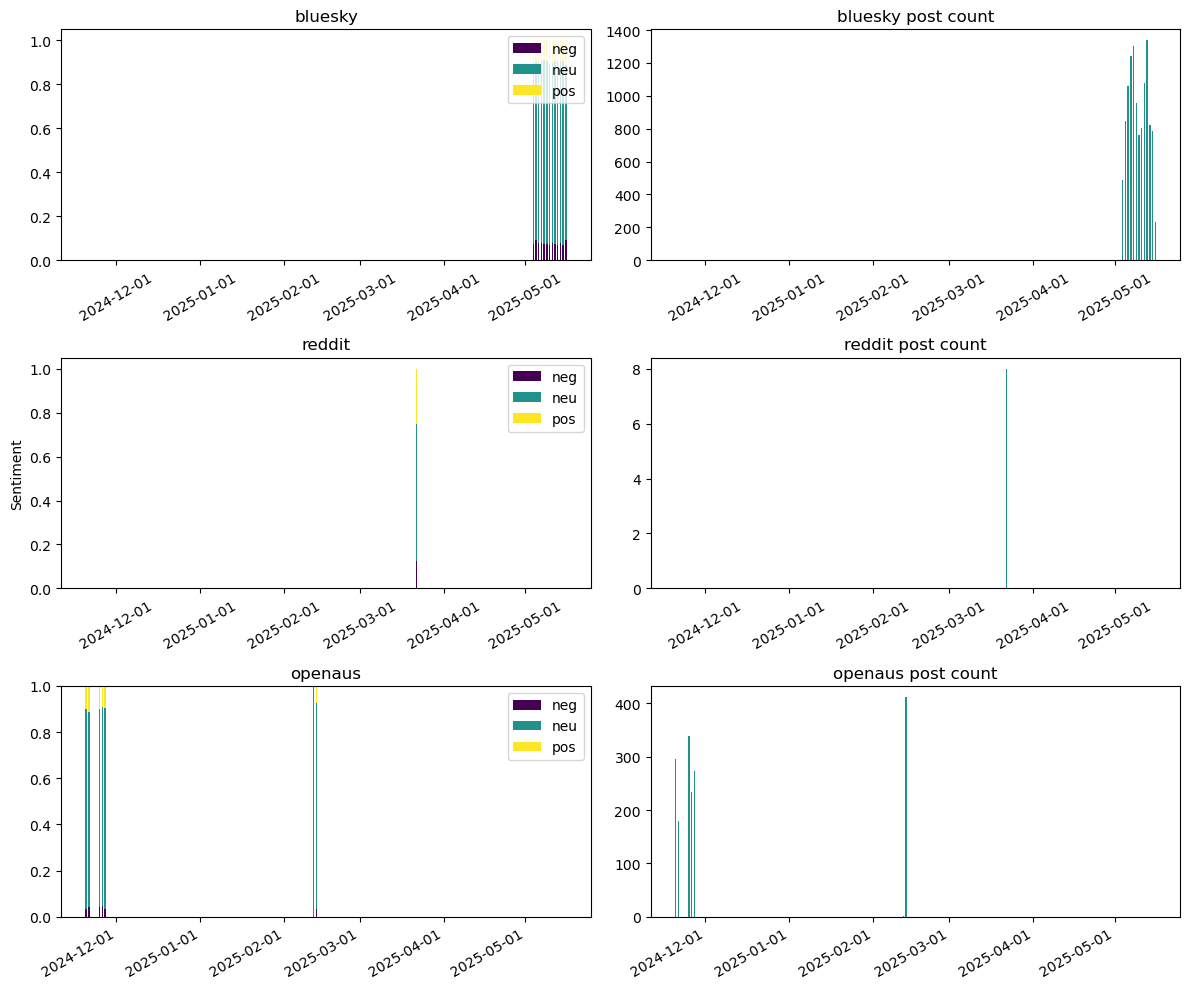

In [ ]:
# colors
cmap = plt.colormaps['viridis']
colors = cmap(np.linspace(0, 1, 3))

# set up the figure layout
fig, ax = plt.subplots(3, 2, sharex=True, figsize=(12, 10))
ax[int(len(keys) / 2),0].set_ylabel("Sentiment", loc="center")
bottom = np.zeros(len(df["bluesky"]["neg"]))

# plot the data
for i, s in enumerate(keys):
    temp_df = df[s]

    total = temp_df['neg'] + temp_df['neu'] + temp_df['pos']

    bottom = np.zeros(len(temp_df["neg"])) 

    for j, col in enumerate(['neg', 'neu', 'pos']):
        ax[i,0].bar(temp_df.index, temp_df[col] / total, 0.5, label=col, color=colors[j], bottom=bottom)
        bottom += temp_df[col] / total
    
    ax[i,0].legend(loc="upper right")
    ax[i,0].set_title(s)
    ax[i,0].set_ylim(bottom=0)

    ax[i, 1].bar(temp_df.index, total, 0.5, label=col, color=colors[1])
    ax[i,1].set_title(s + " post count")
    ax[i,1].set_ylim(bottom=0)

# show the dates as x axis labels
for i in range(3):
    for j in range(2):
        ax[i, j].xaxis.set_major_locator(plt.matplotlib.dates.AutoDateLocator())
        ax[i, j].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
        for label in ax[i, j].get_xticklabels():
            label.set_rotation(30)
            label.set_ha('right')
        ax[i, j].tick_params(axis='x', which='both', labelbottom=True, rotation=30)

plt.tight_layout()
plt.show()


In [44]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/ORG",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - org")
    plt.show()

<Response [404]>


JSONDecodeError: Extra data: line 1 column 5 (char 4)

In [ ]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/LOC",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - loc")
    plt.show()

In [40]:
response = requests.get(
        url=f"{fission}/ui/named-entities/count/100/label/PERSON",
        timeout=600
    )

print(response)
data = response.json()

for s in ["bluesky"]:
    wordcloud = WordCloud(background_color="white", max_font_size=40).generate_from_frequencies(data[s])
    plt.figure(figsize=(8,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(s + " - person")
    plt.show()

<Response [404]>


JSONDecodeError: Extra data: line 1 column 5 (char 4)

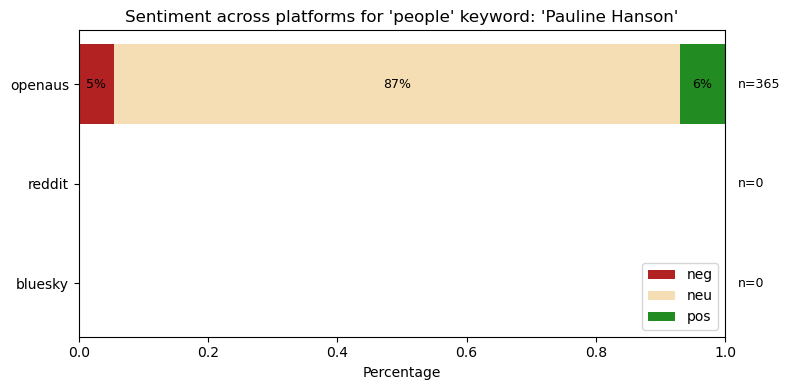

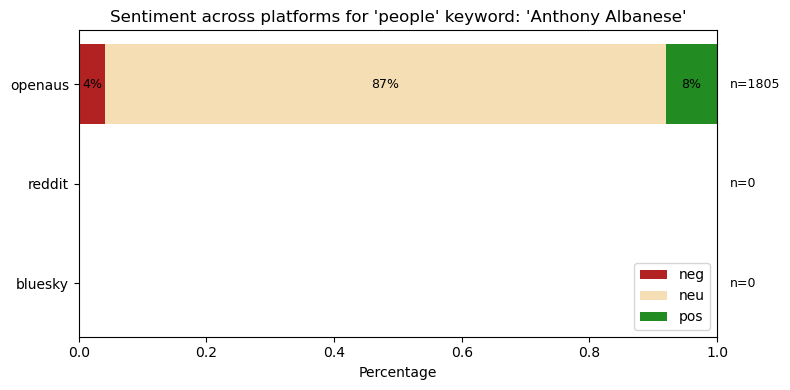

In [100]:

def plot_sentiment_across_platforms(fission_url, keyword_list, keyword_type, results=None):
    """
    Gets the averaged sentiments by keyword from the sentiment-averager Fission function
    and plots sentiment for each keyword across platforms (reddit, bluesky, openaus).
    and displays the results in a nice little horizontal stacked bar chart. yay!
    """
    if results is None:
      # allows testing without having to calculate every tiem yay!
      url = f"{fission_url}/ui/sentiment-averager/type/{keyword_type}"
      headers = {"X-Fission-Params-type": keyword_type}
      data = {"keywords": keyword_list}
      response = requests.post(url, headers=headers, json=data, timeout=120)
      if response.status_code != 200:
          print("Error:", response.text)
          return

      results = response.json()

    platforms = ["bluesky", "reddit", "openaus"]
    # ignore compound 
    sentiment_keys = ["neg", "neu", "pos"] # "compound"]
    # i really love the python colors theyre so funny to me
    colors = ["firebrick", "wheat", "forestgreen"]  

    for keyword in keyword_list:
        # format data 
        sentiment_data = []
        counts = []
        for platform in platforms:
            platform_data = results.get(platform, {}).get(keyword, {})
            sentiment = platform_data.get("sentiment", None)
            count = platform_data.get("count", 0)
            if sentiment:
                sentiment_data.append([sentiment.get(k, 0) for k in sentiment_keys])
            else:
                sentiment_data.append([0, 0, 0])
            counts.append(count)

        sentiment_data = np.array(sentiment_data)

        # stacked bar chart!
        y = np.arange(len(platforms))
        fig, ax = plt.subplots(figsize=(8, 4))
        left = np.zeros(len(platforms))
        for i, sentiment_key in enumerate(sentiment_keys):
            ax.barh(y, sentiment_data[:, i], color=colors[i], label=sentiment_key, left=left)
            left += sentiment_data[:, i]

        ax.set_yticks(y)
        ax.set_yticklabels(platforms)
        ax.set_xlabel("Percentage")
        ax.set_xlim(0, 1)
        ax.set_title(f"Sentiment across platforms for '{keyword_type}' keyword: '{keyword}'")
        ax.legend(loc="lower right")

        # percentage labels and counts
        for i in range(len(platforms)):
            xpos = 0
            for j in range(len(sentiment_keys)):
                width = sentiment_data[i, j]
                # only if theres data 
                if width > 0: 
                    ax.text(xpos + width/2, i, f"{int(width*100)}%", va='center', ha='center', color="black", fontsize=9)
                xpos += width
            ax.text(1.02, i, f"n={counts[i]}", va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()
    return results

results = plot_sentiment_across_platforms(
    fission_url=fission,
    keyword_list=["Pauline Hanson", "Anthony Albanese"],
    keyword_type="people",
    results=results
)